# Hypothesis: Lower income groups have higher obesity rates compared to higher income groups accross U.S states

# Problem Statement 

This project investigates whether income level is related to adult obesity rates in the United States. The dataset includes obesity percentages by state, year, and demographic group. I will focus on income-based stratifications and compare obesity rates across income groups to determine whether lower income groups experience higher obesity rates than higher income groups.

# How I will validate or Disprove the Hypothesis 

To validate or disprove the hypothesis, I will filter the dataset to only include rows where the stratification category is Income. Then, I will select the columns needed for analysis, including year, state, income group, and obesity percentage. Using Spark DataFrame methods, I will calculate the average obesity rate for each income group. If lower income groups show higher average obesity rates than higher income groups, the hypothesis will be supported.

In [3]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.remote("sc://localhost").getOrCreate()
spark

In [5]:
import os
os.getcwd()

'/home/analytics4220/Yangchen'

In [6]:
df = spark.read.csv("/home/analytics4220/Yangchen/obesity.csv", 
                    header=True, quote='"')
df

DataFrame[YearStart: string, YearEnd: string, LocationAbbr: string, LocationDesc: string, Datasource: string, Class: string, Topic: string, Question: string, Data_Value_Unit: string, Data_Value_Type: string, Data_Value: string, Data_Value_Alt: string, Data_Value_Footnote_Symbol: string, Data_Value_Footnote: string, Low_Confidence_Limit: string, High_Confidence_Limit : string, Sample_Size: string, Total: string, Age(years): string, Education: string, Sex: string, Income: string, Race/Ethnicity: string, GeoLocation: string, ClassID: string, TopicID: string, QuestionID: string, DataValueTypeID: string, LocationID: string, StratificationCategory1: string, Stratification1: string, StratificationCategoryId1: string, StratificationID1: string]

First few rows 

In [7]:
df.head(5)

[Row(YearStart='2011', YearEnd='2011', LocationAbbr='AL', LocationDesc='Alabama', Datasource='Behavioral Risk Factor Surveillance System', Class='Obesity / Weight Status', Topic='Obesity / Weight Status', Question='Percent of adults aged 18 years and older who have obesity', Data_Value_Unit=None, Data_Value_Type='Value', Data_Value='34.8', Data_Value_Alt='34.8', Data_Value_Footnote_Symbol=None, Data_Value_Footnote=None, Low_Confidence_Limit='31.3', High_Confidence_Limit ='38.5', Sample_Size='1367', Total=None, Age(years)=None, Education=None, Sex=None, Income='$15,000 - $24,999', Race/Ethnicity=None, GeoLocation='(32.840571122, -86.631860762)', ClassID='OWS', TopicID='OWS1', QuestionID='Q036', DataValueTypeID='VALUE', LocationID='01', StratificationCategory1='Income', Stratification1='$15,000 - $24,999', StratificationCategoryId1='INC', StratificationID1='INC1525'),
 Row(YearStart='2011', YearEnd='2011', LocationAbbr='AL', LocationDesc='Alabama', Datasource='Behavioral Risk Factor Surv

Select columns needed for this project

In [8]:

selected_df = df.select(
    "YearStart",
    "LocationDesc",
    "Question",
    "Data_Value",
    "StratificationCategory1",
    "Stratification1"
)

selected_df.show(10, truncate=False)

+---------+------------+----------------------------------------------------------+----------+-----------------------+------------------+
|YearStart|LocationDesc|Question                                                  |Data_Value|StratificationCategory1|Stratification1   |
+---------+------------+----------------------------------------------------------+----------+-----------------------+------------------+
|2011     |Alabama     |Percent of adults aged 18 years and older who have obesity|34.8      |Income                 |$15,000 - $24,999 |
|2011     |Alabama     |Percent of adults aged 18 years and older who have obesity|35.8      |Income                 |$25,000 - $34,999 |
|2011     |Alabama     |Percent of adults aged 18 years and older who have obesity|32.3      |Income                 |$35,000 - $49,999 |
|2011     |Alabama     |Percent of adults aged 18 years and older who have obesity|34.1      |Income                 |$50,000 - $74,999 |
|2011     |Alabama     |Percent of

Convert Data_Value from string to double 

In [9]:
clean_df = selected_df.withColumn(
    "Data_Value",
    col("Data_Value").cast("double")
)

Filter only income rows and obesity question

In [10]:
income_df = clean_df.filter(
    (col("StratificationCategory1") == "Income") &
    (col("Question") == "Percent of adults aged 18 years and older who have obesity") &
    (col("Data_Value").isNotNull())
)

income_df.show(10, truncate=False)

+---------+------------+----------------------------------------------------------+----------+-----------------------+------------------+
|YearStart|LocationDesc|Question                                                  |Data_Value|StratificationCategory1|Stratification1   |
+---------+------------+----------------------------------------------------------+----------+-----------------------+------------------+
|2011     |Alabama     |Percent of adults aged 18 years and older who have obesity|34.8      |Income                 |$15,000 - $24,999 |
|2011     |Alabama     |Percent of adults aged 18 years and older who have obesity|35.8      |Income                 |$25,000 - $34,999 |
|2011     |Alabama     |Percent of adults aged 18 years and older who have obesity|32.3      |Income                 |$35,000 - $49,999 |
|2011     |Alabama     |Percent of adults aged 18 years and older who have obesity|34.1      |Income                 |$50,000 - $74,999 |
|2011     |Alabama     |Percent of

Calculate average obesity rate by income group 

In [11]:
income_result = income_df.groupBy("Stratification1").agg(
    round(avg("Data_Value"), 2).alias("Average_Obesity_Rate"),
    count("*").alias("Number_of_Records")
).orderBy("Average_Obesity_Rate", ascending=False)

income_result.show(truncate=False)

+------------------+--------------------+-----------------+
|Stratification1   |Average_Obesity_Rate|Number_of_Records|
+------------------+--------------------+-----------------+
|Less than $15,000 |35.84               |751              |
|$15,000 - $24,999 |34.67               |751              |
|$25,000 - $34,999 |33.28               |751              |
|$35,000 - $49,999 |32.87               |751              |
|$50,000 - $74,999 |32.28               |750              |
|$75,000 or greater|29.02               |751              |
|Data not reported |26.82               |751              |
+------------------+--------------------+-----------------+



The difference between the poorest and the richest is 6.82, which is pretty significant 

# Visualization

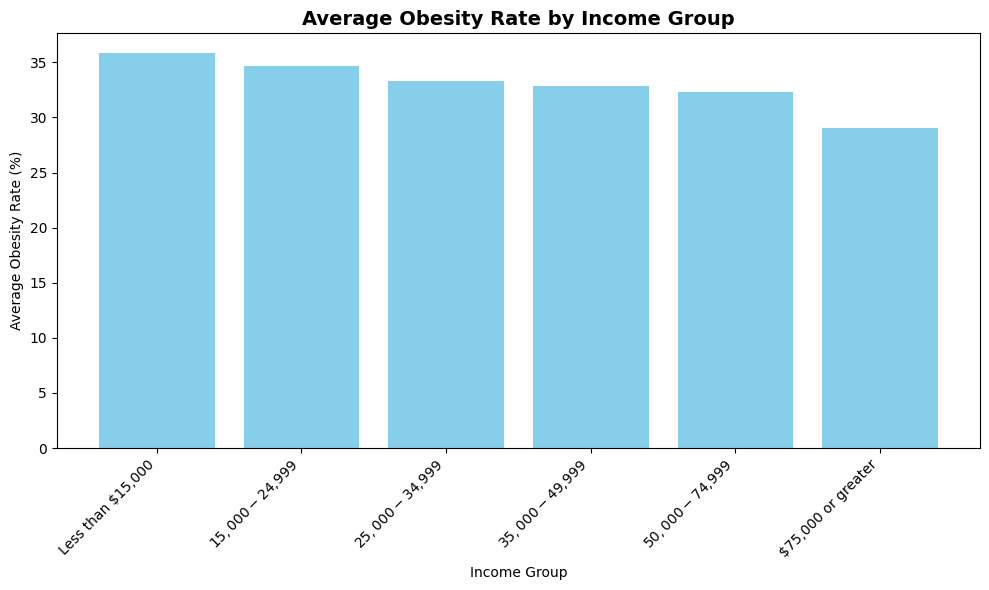

In [14]:
import matplotlib.pyplot as plt

# Convert Spark DataFrame to Pandas
pdf = income_result.toPandas()

# Remove "Data not reported"
pdf = pdf[pdf["Stratification1"] != "Data not reported"]

# Create chart
plt.figure(figsize=(10,6))

plt.bar(
    pdf["Stratification1"],
    pdf["Average_Obesity_Rate"]
)

plt.title("Average Obesity Rate by Income Group", fontsize=14, fontweight='bold')
plt.xlabel("Income Group")
plt.ylabel("Average Obesity Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.bar(pdf["Stratification1"], pdf["Average_Obesity_Rate"], color="skyblue")

plt.show()

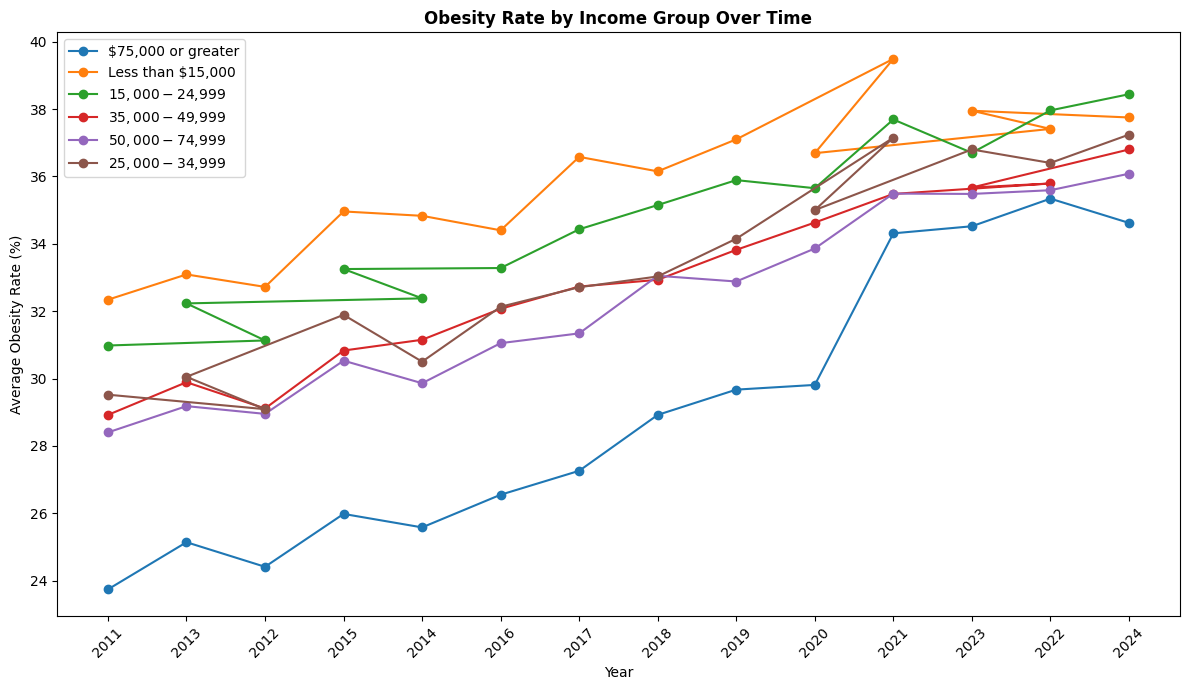

In [15]:
from pyspark.sql.functions import avg, round
import matplotlib.pyplot as plt

year_df = income_df.groupBy("YearStart", "Stratification1").agg(
    round(avg("Data_Value"),2).alias("AvgRate")
)

pdf = year_df.toPandas()

plt.figure(figsize=(12,7))

for group in pdf["Stratification1"].unique():
    subset = pdf[pdf["Stratification1"] == group]
    if group != "Data not reported":
        plt.plot(subset["YearStart"], subset["AvgRate"], marker='o', label=group)

plt.title("Obesity Rate by Income Group Over Time", fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Average Obesity Rate (%)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

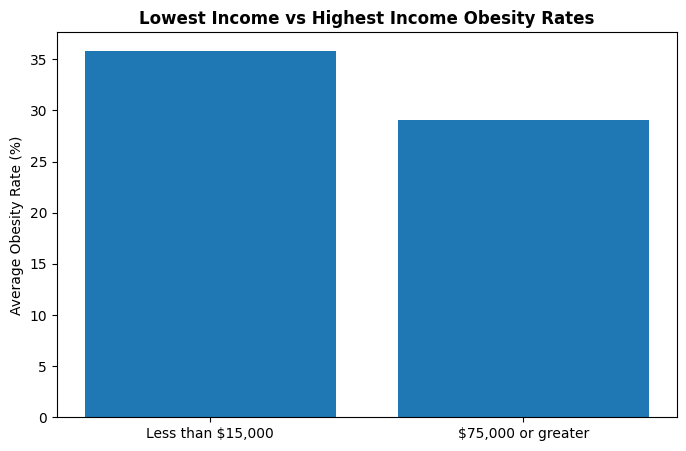

In [18]:
compare = income_result.toPandas()

compare = compare[
    compare["Stratification1"].isin(
        ["Less than $15,000", "$75,000 or greater"]
    )
]
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.bar(compare["Stratification1"], compare["Average_Obesity_Rate"])
plt.title("Lowest Income vs Highest Income Obesity Rates", fontweight="bold")
plt.ylabel("Average Obesity Rate (%)")
plt.show()

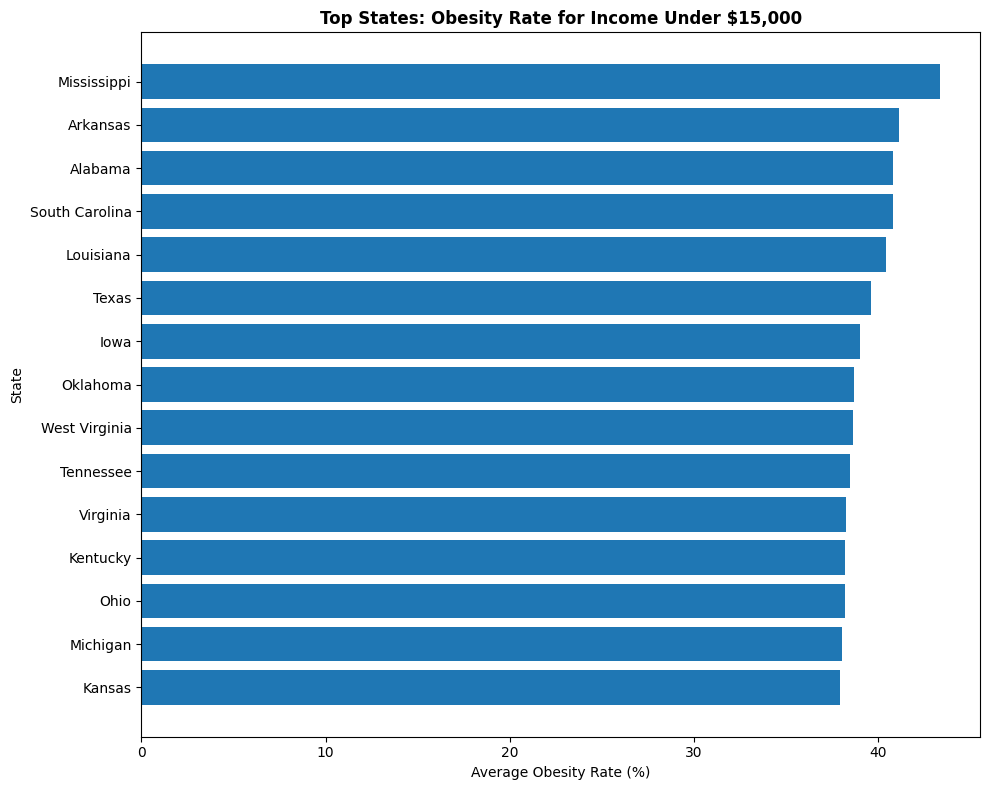

In [19]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import col, avg, round

# Lowest income group
low_income_state = income_df.filter(
    col("Stratification1") == "Less than $15,000"
)

# Average obesity by state
state_df = low_income_state.groupBy(
    "LocationDesc"
).agg(
    round(avg("Data_Value"),2).alias("Average_Obesity_Rate")
).orderBy("Average_Obesity_Rate", ascending=False)

# Convert to pandas
pdf = state_df.toPandas()

# Top 15 highest states
top15 = pdf.head(15)

plt.figure(figsize=(10,8))
plt.barh(
    top15["LocationDesc"],
    top15["Average_Obesity_Rate"]
)

plt.title("Top States: Obesity Rate for Income Under $15,000", fontweight="bold")
plt.xlabel("Average Obesity Rate (%)")
plt.ylabel("State")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Result

The analysis supports the hypothesis that lower income groups have higher obesity rates than higher income groups across U.S. states. The lowest income group (Less than $15,000) had the highest average obesity rate at 35.84%, while the highest income group ($75,000 or greater) had the lowest average obesity rate at 29.02%. This suggests an inverse relationship between income and obesity rates.

In [21]:
# Save result as part file
income_result.write.mode("overwrite").csv(
    "output/income_obesity_results",
    header=True
)